# Nivel 1: clasificacion de capitulos CIE-10 con ModernBERT

Cuaderno dedicado a `answerdotai/ModernBERT-base` sobre nivel 1 (capitulos, multi-etiqueta),
con la misma configuracion que los cuadernos de RoBERTa, RigoBERTa y mmBERT para que las
cifras sean comparables.


## 1. Configuración e Importación

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

# Verificar/instalar dependencias
try:
    import torch
    import transformers
    import datasets
except ImportError:
    print(" Instalando dependencias...")
    !{sys.executable} -m pip install -q torch transformers datasets scikit-learn pandas numpy tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from tqdm.auto import tqdm
import os
import json
from pathlib import Path
from collections import defaultdict
import re

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
# Flag para activar/desactivar limpieza de texto
CLEAN_TEXT = True  # Cambiar a True si quieres limpiar el texto

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Dispositivo: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("     CPU detectado (entrenamiento será más lento)")

# Rutas
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / "csv_import_scripts" / "codiesp_csvs"
SNAPSHOTS_DIR = PROJECT_ROOT / "snapshots"
LEVEL1_DIR = SNAPSHOTS_DIR / "nivel1_capitulos"
LEVEL2_DIR = SNAPSHOTS_DIR / "nivel2_codigos"

# Crear directorios
for dir_path in [SNAPSHOTS_DIR, LEVEL1_DIR, LEVEL2_DIR]:

    dir_path.mkdir(exist_ok=True, parents=True)

print(f"\n Limpieza de texto: {' ACTIVADA' if CLEAN_TEXT else ' DESACTIVADA'}")

print(f"\n Rutas:")
print(f"   Dataset: {DATA_DIR}")
print(f"   Nivel 1: {LEVEL1_DIR}")
print(f"   Nivel 2: {LEVEL2_DIR}")

  Dispositivo: cuda
   GPU: NVIDIA GeForce RTX 4080

 Limpieza de texto:  ACTIVADA

 Rutas:
   Dataset: /home/cie10user/csv_import_scripts/codiesp_csvs
   Nivel 1: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos
   Nivel 2: /home/cie10user/bert-classifier/snapshots/nivel2_codigos


## 2. Configuración de Hiperparámetros

In [2]:
from huggingface_hub import login

class Config:
    """Configuración global del sistema"""

    # HuggingFace Token
    HF_TOKEN = os.getenv("HF_TOKEN", None)

    # ============================================================================
    # MODELOS DISPONIBLES
    # ============================================================================

    # 1. RoBERTa Médico Español (Baseline)
    MODEL_ROBERTA_MEDICAL = 'PlanTL-GOB-ES/roberta-base-biomedical-clinical-es'
    ROBERTA_MAX_LENGTH = 512
    ROBERTA_BATCH_SIZE = 16 if device.type == 'cuda' else 8

    # 3. mmBERT (Modern Multilingual BERT - 100+ idiomas)
    MODEL_MMBERT = 'jhu-clsp/mmBERT-base'
    MMBERT_MAX_LENGTH = 1500  # Soporta hasta 4096 pero usamos 1500 para balance
    MMBERT_BATCH_SIZE = 12 if device.type == 'cuda' else 6

    # 4. ModernBERT (Estado del arte 2024 - Flash Attention)
    MODEL_MODERNBERT = 'answerdotai/ModernBERT-base'
    MODERNBERT_MAX_LENGTH = 1500  # Máximo contexto
    MODERNBERT_BATCH_SIZE = 4 if device.type == 'cuda' else 2  # Muy largo, reduce batch

    # Modelo por defecto para inicio rápido
    MODEL_NAME = MODEL_ROBERTA_MEDICAL
    MAX_LENGTH = ROBERTA_MAX_LENGTH

    # ============================================================================
    # ENTRENAMIENTO
    # ============================================================================

    # Batch sizes - Adaptativo según hardware
    if device.type == 'cuda':
        BATCH_SIZE_LEVEL1 = 8# Nivel 1 (solo 19 clases)
        BATCH_SIZE_LEVEL2 = 8   # Nivel 2 (más clases por capítulo)
        ACCUMULATION_STEPS = 2
    else:
        BATCH_SIZE_LEVEL1 = 8# CPU
        BATCH_SIZE_LEVEL2 = 4
        ACCUMULATION_STEPS = 4

    # DataLoader workers
    #  IMPORTANTE: En Jupyter notebooks, SIEMPRE usar NUM_WORKERS = 0
    # Razón: PyTorch con num_workers > 0 usa multiprocessing (spawn) que intenta
    # serializar las clases Dataset con pickle. Las clases definidas en notebooks
    # están en el módulo '__main__' que no se puede serializar correctamente.
    # Error típico: "AttributeError: module '__main__' has no attribute 'ChapterDataset'"
    # Solución: num_workers=0 ejecuta todo en el proceso principal sin multiprocessing.
    # En scripts .py normales, puedes usar NUM_WORKERS = 2-4 para acelerar carga de datos.
    NUM_WORKERS = 0  # SIEMPRE 0 en Jupyter notebooks

    # Épocas
    EPOCHS_LEVEL1 = 200# Nivel 1 (parará antes con early stopping si converge)
    EPOCHS_LEVEL2 = 60  # Nivel 2 (parará antes con early stopping si converge)
    EARLY_STOPPING_PATIENCE = 40# Parar si no mejora en sucesivas épocas
    MIN_DELTA = 0.0001  # Mejora mínima para considerar que hubo progreso

    # Optimización
    LEARNING_RATE = 3e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    MAX_GRAD_NORM = 1.0
    DROPOUT = 0.1

    # Dataset
    TRAIN_PATH = DATA_DIR / 'codiesp_D_source_train.csv'
    VAL_PATH = DATA_DIR / 'codiesp_D_source_validation.csv'
    TEST_PATH = DATA_DIR / 'codiesp_D_source_test.csv'

    # Cascada
    TOP_K_CHAPTERS = 3  # Top-3 capítulos en Nivel 1
    TOP_K_CODES_PER_CHAPTER = 5  # Top-5 códigos por capítulo
    FINAL_TOP_K = 10  # Top-10 códigos finales

    # Paths
    LEVEL1_DIR = LEVEL1_DIR
    LEVEL2_DIR = LEVEL2_DIR

    # Umbrales
    #  IMPORTANTE: Thresholds bajos permiten más recall, altos más precision
    # Ajustar según distribución real de labels por documento (ver celda de análisis)
    THRESHOLD_LEVEL1 = 0.2# Umbral para capítulos (0.3 = más permisivo)
    THRESHOLD_LEVEL2 = 0.3  # Umbral para códigos (0.3 recomendado vs 0.5 muy restrictivo)

config = Config()

# Configurar HuggingFace login
if config.HF_TOKEN:
    try:
        login(token=config.HF_TOKEN)
        print(" HuggingFace login exitoso")
    except Exception as e:
        print(f" Error en HF login: {e}")
else:
    print(" HF_TOKEN no configurado (export HF_TOKEN='tu_token')")

print("\n  Configuración:")
print(f"   Modelo por defecto: {config.MODEL_NAME}")
print(f"   Max Length: {config.MAX_LENGTH}")
print(f"   Batch Level 1: {config.BATCH_SIZE_LEVEL1}")
print(f"   Batch Level 2: {config.BATCH_SIZE_LEVEL2}")
print(f"   Épocas Level 1: {config.EPOCHS_LEVEL1}")
print(f"   Épocas Level 2: {config.EPOCHS_LEVEL2}")
print(f"   Cascada: Top-{config.TOP_K_CHAPTERS} capítulos → Top-{config.TOP_K_CODES_PER_CHAPTER} códigos/cap")
print(f"   Output final: Top-{config.FINAL_TOP_K} códigos")

print("\n Modelos disponibles:")
print(f"   1. RoBERTa Médico:  {config.MODEL_ROBERTA_MEDICAL} ({config.ROBERTA_MAX_LENGTH} tokens)")
print(f"   3. mmBERT:          {config.MODEL_MMBERT} ({config.MMBERT_MAX_LENGTH} tokens)")
print(f"   4. ModernBERT:      {config.MODEL_MODERNBERT} ({config.MODERNBERT_MAX_LENGTH} tokens)")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


 HuggingFace login exitoso

  Configuración:
   Modelo por defecto: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
   Max Length: 512
   Batch Level 1: 8
   Batch Level 2: 8
   Épocas Level 1: 200
   Épocas Level 2: 60
   Cascada: Top-3 capítulos → Top-5 códigos/cap
   Output final: Top-10 códigos

 Modelos disponibles:
   1. RoBERTa Médico:  PlanTL-GOB-ES/roberta-base-biomedical-clinical-es (512 tokens)
   3. mmBERT:          jhu-clsp/mmBERT-base (1500 tokens)
   4. ModernBERT:      answerdotai/ModernBERT-base (1500 tokens)


###  Comparación de Modelos Disponibles

| Modelo | Max Tokens | Idiomas | Dominio | Batch Size | Velocidad | Ventajas |
|--------|------------|---------|---------|------------|-----------|----------|
| **RoBERTa Médico** | 512 | Español | Médico | 16 |  Rápido | Conocimiento médico español |
| **Longformer** | 4096 | Inglés | General | 8 |  Medio | Textos muy largos |
| **mmBERT** | 1500 | 100+ | General | 12 |  Medio | Multilingüe + textos largos |
| **ModernBERT** | 8192 | Inglés | General | 4 |  Lento | Ultra-largos + Flash Attention |

**Recomendaciones:**
- **Textos < 512 tokens:** RoBERTa Médico (mejor conocimiento de dominio)
- **Textos 512-2048:** mmBERT (multilingüe + buen balance)
- **Textos 2048-4096:** Longformer (si inglés es aceptable)
- **Textos > 4096:** ModernBERT (máxima capacidad)

## 3. Mapeo de Capítulos CIE-10

In [3]:
# Mapeo oficial de capítulos CIE-10 (usando letras como keys)
CIE10_CHAPTERS = {
    'A': {'name': 'Enfermedades infecciosas y parasitarias', 'range': 'A00-B99', 'roman': 'I'},
    'C': {'name': 'Neoplasias', 'range': 'C00-D48', 'roman': 'II'},
    'D': {'name': 'Enfermedades de la sangre', 'range': 'D50-D89', 'roman': 'III'},
    'E': {'name': 'Enfermedades endocrinas, nutricionales y metabólicas', 'range': 'E00-E90', 'roman': 'IV'},
    'F': {'name': 'Trastornos mentales y del comportamiento', 'range': 'F00-F99', 'roman': 'V'},
    'G': {'name': 'Enfermedades del sistema nervioso', 'range': 'G00-G99', 'roman': 'VI'},
    'H': {'name': 'Enfermedades del ojo y oído', 'range': 'H00-H95', 'roman': 'VII-VIII'},
    'I': {'name': 'Enfermedades del sistema circulatorio', 'range': 'I00-I99', 'roman': 'IX'},
    'J': {'name': 'Enfermedades del sistema respiratorio', 'range': 'J00-J99', 'roman': 'X'},
    'K': {'name': 'Enfermedades del sistema digestivo', 'range': 'K00-K93', 'roman': 'XI'},
    'L': {'name': 'Enfermedades de la piel y del tejido subcutáneo', 'range': 'L00-L99', 'roman': 'XII'},
    'M': {'name': 'Enfermedades del sistema osteomuscular', 'range': 'M00-M99', 'roman': 'XIII'},
    'N': {'name': 'Enfermedades del sistema genitourinario', 'range': 'N00-N99', 'roman': 'XIV'},
    'O': {'name': 'Embarazo, parto y puerperio', 'range': 'O00-O99', 'roman': 'XV'},
    'P': {'name': 'Afecciones originadas en el período perinatal', 'range': 'P00-P96', 'roman': 'XVI'},
    'Q': {'name': 'Malformaciones congénitas', 'range': 'Q00-Q99', 'roman': 'XVII'},
    'R': {'name': 'Síntomas, signos y hallazgos anormales', 'range': 'R00-R99', 'roman': 'XVIII'},
    'S': {'name': 'Traumatismos, envenenamientos', 'range': 'S00-T98', 'roman': 'XIX'},
    'V': {'name': 'Causas externas de morbilidad y mortalidad', 'range': 'V01-Y98', 'roman': 'XX'},
    'Z': {'name': 'Factores que influyen en el estado de salud', 'range': 'Z00-Z99', 'roman': 'XXI'},
}

def extract_chapter_from_code(code):
    """Extraer capítulo CIE-10 del código (retorna letra)"""
    if not code or len(code) == 0:
        return None

    # Obtener primera letra del código
    first_letter = code[0].upper()

    # Mapeo directo letra → capítulo
    # Casos especiales:
    if first_letter == 'B':
        return 'A'  # B pertenece al capítulo A (infecciosas)
    elif first_letter == 'D':
        # D00-D48 = Neoplasias (C), D50-D89 = Sangre (D)
        if len(code) > 1:
            try:
                num = int(code[1:3])
                if num >= 50:
                    return 'D'  # Enfermedades de la sangre
            except:
                pass
        return 'C'  # Neoplasias
    elif first_letter == 'T':
        return 'S'  # T pertenece a traumatismos (S)
    elif first_letter in ['W', 'X', 'Y']:
        return 'V'  # Pertenecen a causas externas (V)

    # Resto de letras son mapeo directo
    if first_letter in CIE10_CHAPTERS:
        return first_letter

    return None

print(f" Capítulos CIE-10 definidos: {len(CIE10_CHAPTERS)}")
print(f"\n Ejemplos de DIRECT mapping (letra = capítulo):")
direct_codes = ['A00', 'C50', 'E11', 'I10', 'J44', 'M79']
for code in direct_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter}: {CIE10_CHAPTERS[chapter]['name']}")

print(f"\n  Ejemplos de EDGE CASES (letra ≠ capítulo):")
edge_codes = [
    ('B15', 'B→A: Hepatitis A es infecciosa'),
    ('D05', 'D→C: Neoplasia in situ (D<50)'),
    ('D50', 'D→D: Anemia (D≥50)'),
    ('T14', 'T→S: Traumatismo'),
    ('W19', 'W→V: Caída (causa externa)'),
    ('X59', 'X→V: Exposición a factores'),
    ('Y84', 'Y→V: Complicación de procedimiento')
]
for code, description in edge_codes:
    chapter = extract_chapter_from_code(code)
    if chapter:
        print(f"   {code} → Cap. {chapter} ({description})")

 Capítulos CIE-10 definidos: 20

 Ejemplos de DIRECT mapping (letra = capítulo):
   A00 → Cap. A: Enfermedades infecciosas y parasitarias
   C50 → Cap. C: Neoplasias
   E11 → Cap. E: Enfermedades endocrinas, nutricionales y metabólicas
   I10 → Cap. I: Enfermedades del sistema circulatorio
   J44 → Cap. J: Enfermedades del sistema respiratorio
   M79 → Cap. M: Enfermedades del sistema osteomuscular

  Ejemplos de EDGE CASES (letra ≠ capítulo):
   B15 → Cap. A (B→A: Hepatitis A es infecciosa)
   D05 → Cap. C (D→C: Neoplasia in situ (D<50))
   D50 → Cap. D (D→D: Anemia (D≥50))
   T14 → Cap. S (T→S: Traumatismo)
   W19 → Cap. V (W→V: Caída (causa externa))
   X59 → Cap. V (X→V: Exposición a factores)
   Y84 → Cap. V (Y→V: Complicación de procedimiento)


###  Explicación del Mapeo de Capítulos CIE-10

**¿Por qué este mapeo?**

La CIE-10 oficial usa **21 capítulos con numeración romana** (I-XXI), pero los **códigos reales usan letras** que NO siempre coinciden con el número de capítulo. Esto crea inconsistencias históricas de la OMS.

---

###  Capítulos que Juntan Múltiples Letras (NO Direct Mapping)

#### **1. Capítulo A (Infecciosas): A00-B99**
**¿Por qué?** La OMS decidió que códigos `A` y `B` pertenecen al mismo capítulo semántico.

**Ejemplos:**
- `A00` → Cólera → Capítulo **A**  (direct mapping)
- `A09` → Diarrea infecciosa → Capítulo **A** 
- `B15` → Hepatitis A → Capítulo **A**  (letra B, pero capítulo A)
- `B34` → Infección viral no especificada → Capítulo **A** 
- `B99` → Otras enfermedades infecciosas → Capítulo **A** 

**Regla:** `B → A` (todas las B son infecciosas)

---

#### **2. Capítulo C (Neoplasias): C00-D48**
**¿Por qué?** Las neoplasias incluyen tumores malignos (C) y benignos/inciertos (D00-D48).

**Ejemplos:**
- `C50` → Tumor maligno de mama → Capítulo **C**  (direct mapping)
- `C34` → Tumor maligno de bronquios y pulmón → Capítulo **C** 
- `D05` → Carcinoma in situ de mama → Capítulo **C**  (letra D, pero capítulo C)
- `D23` → Nevus melanocítico → Capítulo **C** 
- `D48` → Tumor de comportamiento incierto → Capítulo **C** 

**Regla:** `D00-D48 → C` (neoplasias benignas/inciertas)

---

#### **3. Capítulo D (Sangre): D50-D89**
**¿Por qué?** Después de D48, los códigos D50+ cambian a enfermedades de la sangre.

**Ejemplos:**
- `D50` → Anemia por deficiencia de hierro → Capítulo **D** 
- `D64` → Otras anemias → Capítulo **D** 
- `D68` → Trastornos de la coagulación → Capítulo **D** 
- `D89` → Trastornos inmunitarios → Capítulo **D** 

**Regla:** `D50-D89 → D` (enfermedades de la sangre)

** EDGE CASE CRÍTICO:** 
- `D10` → Neoplasia → Capítulo **C**
- `D50` → Anemia → Capítulo **D**
- **Misma letra, diferentes capítulos** (se diferencia por número)

---

#### **4. Capítulo S (Traumatismos): S00-T98**
**¿Por qué?** Lesiones, traumatismos y envenenamientos se agrupan semánticamente.

**Ejemplos:**
- `S62` → Fractura de muñeca → Capítulo **S**  (direct mapping)
- `S06` → Traumatismo intracraneal → Capítulo **S** 
- `T14` → Traumatismo de región no especificada → Capítulo **S**  (letra T, pero capítulo S)
- `T30` → Quemadura térmica → Capítulo **S** 
- `T88` → Complicaciones de atención médica → Capítulo **S** 

**Regla:** `T → S` (todas las T son traumatismos/lesiones)

---

#### **5. Capítulo V (Causas Externas): V01-Y98**
**¿Por qué?** Incluye accidentes, violencia, circunstancias de lesión (códigos V, W, X, Y).

**Ejemplos:**
- `V01` → Peatón lesionado por vehículo → Capítulo **V**  (direct mapping)
- `V89` → Accidente de tránsito → Capítulo **V** 
- `W19` → Caída no especificada → Capítulo **V**  (letra W)
- `X59` → Exposición a factores no especificados → Capítulo **V**  (letra X)
- `Y84` → Complicación de dispositivo médico → Capítulo **V**  (letra Y)

**Regla:** `W, X, Y → V` (causas externas)

---

###  Capítulos con Direct Mapping (Letra = Capítulo)

Estos son más simples:
- `E11` → Diabetes tipo 2 → Capítulo **E** 
- `F32` → Depresión → Capítulo **F** 
- `G40` → Epilepsia → Capítulo **G** 
- `H25` → Catarata → Capítulo **H** 
- `I10` → Hipertensión → Capítulo **I** 
- `J44` → EPOC → Capítulo **J** 
- `K29` → Gastritis → Capítulo **K** 
- `L40` → Psoriasis → Capítulo **L** 
- `M79` → Dolor muscular → Capítulo **M** 
- `N18` → Enfermedad renal crónica → Capítulo **N** 
- `O80` → Parto único espontáneo → Capítulo **O** 
- `P07` → Recién nacido prematuro → Capítulo **P** 
- `Q21` → Malformación cardíaca congénita → Capítulo **Q** 
- `R10` → Dolor abdominal → Capítulo **R** 
- `Z00` → Examen médico general → Capítulo **Z** 

---

###  Resumen de Mapeo No Directo

| Letra Código | Capítulo Real | Razón |
|--------------|---------------|-------|
| **B** | A (Infecciosas) | Misma categoría semántica |
| **D00-D48** | C (Neoplasias) | Neoplasias benignas/inciertas |
| **D50-D89** | D (Sangre) | **Split numérico crítico** |
| **T** | S (Traumatismos) | Lesiones y envenenamientos |
| **W, X, Y** | V (Causas externas) | Circunstancias de lesión |

**Total:** 5 casos especiales de 26 letras posibles (19% edge cases)

**Estrategia del modelo:** Al clasificar primero por capítulo (20 clases) en lugar de 14,000 códigos directamente, reducimos espacio de búsqueda 95% y mejoramos precisión.

## 4. Carga y Preprocesamiento de Datos

In [4]:
# DEBUG: Ver columnas del CSV
print(" Verificando estructura del CSV...")
test_df = pd.read_csv(config.TRAIN_PATH, sep=',', nrows=2)
print(f"Columnas encontradas: {test_df.columns.tolist()}")
print(f"\nPrimeras 2 filas:")
print(test_df.head(2))

 Verificando estructura del CSV...
Columnas encontradas: ['text', 'labels']

Primeras 2 filas:
                                                text  \
0  Describimos el caso de un varón de 37 años con...   
1  Se trata de una mujer de 29 años sometida a un...   

                                              labels  
0  n44.8;z20.818;r60.9;r52;a23.9;i83.90;i87.8;r50...  
1                                          d30.3;r58  


In [5]:
print(" Cargando datos CODIESP...")

# Cargar datos
train_df = pd.read_csv(config.TRAIN_PATH, sep=',')
dev_df = pd.read_csv(config.VAL_PATH, sep=',')

print(f" Train: {len(train_df)} documentos")
print(f" Dev: {len(dev_df)} documentos")

# Análisis de códigos CIE-10 y distribución por documento
all_codes = set()
chapter_counts = {}
codes_per_doc = []
chapters_per_doc = []

for codes_str in train_df['labels'].dropna():
    codes = [c.strip() for c in codes_str.split(';') if c.strip()]
    all_codes.update(codes)
    codes_per_doc.append(len(codes))

    # Capítulos únicos por documento
    doc_chapters = set()
    for code in codes:
        chapter = extract_chapter_from_code(code)
        if chapter:
            chapter_counts[chapter] = chapter_counts.get(chapter, 0) + 1
            doc_chapters.add(chapter)

    chapters_per_doc.append(len(doc_chapters))

# Estadísticas de labels por documento
import numpy as np
mean_codes = np.mean(codes_per_doc)
median_codes = np.median(codes_per_doc)
max_codes = np.max(codes_per_doc)
mean_chapters = np.mean(chapters_per_doc)
median_chapters = np.median(chapters_per_doc)

print(f"\n Estadísticas:")
print(f"   Total códigos únicos: {len(all_codes)}")
print(f"   Capítulos con datos: {len(chapter_counts)}")

print(f"\n Distribución de labels por documento:")
print(f"   Códigos por doc - Media: {mean_codes:.1f} | Mediana: {median_codes:.0f} | Max: {max_codes}")
print(f"   Capítulos por doc - Media: {mean_chapters:.1f} | Mediana: {median_chapters:.0f}")

print(f"\n Recomendaciones de thresholds:")
print(f"   THRESHOLD_LEVEL1 = 0.3   (permite ~{mean_chapters:.0f} capítulos, media: {mean_chapters:.1f})")
print(f"   THRESHOLD_LEVEL2 = 0.3    (threshold 0.5 puede ser muy alto)")
print(f"   TOP_K = {int(mean_codes + 3)}  (media + margen)")

print(f"\n Top 10 capítulos más frecuentes:")
for chapter, count in sorted(chapter_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"   Cap. {chapter}: {count:,} códigos - {CIE10_CHAPTERS.get(chapter, {}).get('name', 'N/A')}")

 Cargando datos CODIESP...
 Train: 500 documentos
 Dev: 250 documentos

 Estadísticas:
   Total códigos únicos: 1767
   Capítulos con datos: 20

 Distribución de labels por documento:
   Códigos por doc - Media: 11.3 | Mediana: 10 | Max: 40
   Capítulos por doc - Media: 4.9 | Mediana: 5

 Recomendaciones de thresholds:
   THRESHOLD_LEVEL1 = 0.3   (permite ~5 capítulos, media: 4.9)
   THRESHOLD_LEVEL2 = 0.3    (threshold 0.5 puede ser muy alto)
   TOP_K = 14  (media + margen)

 Top 10 capítulos más frecuentes:
   Cap. R: 1,611 códigos - Síntomas, signos y hallazgos anormales
   Cap. K: 432 códigos - Enfermedades del sistema digestivo
   Cap. I: 419 códigos - Enfermedades del sistema circulatorio
   Cap. C: 400 códigos - Neoplasias
   Cap. A: 396 códigos - Enfermedades infecciosas y parasitarias
   Cap. N: 339 códigos - Enfermedades del sistema genitourinario
   Cap. H: 301 códigos - Enfermedades del ojo y oído
   Cap. E: 243 códigos - Enfermedades endocrinas, nutricionales y metabólicas

###  Preprocesamiento de Texto (Opcional) *

*1⃣ ¿Por qué NO necesitamos limpiar como en modelos tradicionales?**

**Respuesta:** Los tokenizers de BERT/RoBERTa **ya están diseñados** para manejar texto "sucio".

**Ejemplo práctico:**
- **Texto original:** `"Paciente con HTA (140/90 mmHg), DM tipo 2 - código E11.9"`
- **Limpieza tradicional (spaCy):** `"paciente hta dm tipo codigo"`  **Perdimos toda la info útil**
- **RoBERTa lo tokeniza:** `["Pac", "##iente", "con", "HTA", "(", "140", "/", "90", "mm", "##Hg", ")"]`

 **RoBERTa entiende puntuación, números, paréntesis** → Todo es información valiosa.

---

### **2⃣ Limpieza que EMPEORA los resultados**

|  No hacer | ¿Por qué? | Ejemplo |
|-------------|-----------|----------|
| **Eliminar stopwords** | "no hay", "sin" cambian el significado | "sin síntomas" vs "síntomas" |
| **Stemming/Lemmatización** | RoBERTa usa subpalabras, no palabras completas | "hipertensión" → "hiperten" (innecesario) |
| **Eliminar puntuación** | Ayuda a separar diagnósticos y entender estructura | "DM2. HTA. EPOC." → clave para multi-label |
| **Eliminar números** | Códigos CIE-10 tienen números | "E11" → "E"  |
| **Lowercase forzado** | RoBERTa lo hace automático | Innecesario y puede confundir abreviaturas |

---

### **3⃣ ¿Cuándo SÍ limpiar? (Limpieza mínima)**

Solo si tienes **problemas técnicos** que el tokenizer no puede manejar:

|  Sí limpiar | ¿Por qué? | Ejemplo |
|---------------|-----------|----------|

| **Caracteres corruptos** | Causan errores de encoding | `�`, `\x00`, `\ufffd` |### ** Vamos a analizar tu dataset:**

| **HTML tags** | No son texto médico | `<p>Diagnóstico</p>` → `Diagnóstico` |

| **URLs** | Raramente relevantes en informes | `http://ejemplo.com` |---

| **Espacios múltiples** | Solo normalizar (no crítico) | `"HTA    DM"` → `"HTA DM"` |

 **La celda siguiente analizará tu texto y te dirá si necesitas limpieza.**

**LO QUE SÍ PRESERVAMOS:**

-  Abreviaturas médicas: `HTA`, `DM`, `EPOC`, `Rx`- **`True`:** Limpieza mínima → Solo si detectamos problemas (caracteres corruptos, HTML, etc.)

-  Símbolos médicos: `%`, `mg/dl`, `mmHg`, `°C`- **`False` (default):** No limpieza → Recomendado si tu dataset es CODIESP oficial

-  Códigos: `E11.9`, `I10`, `J44.0`

-  Puntuación clínica: `.`, `,`, `;`, `-`, `()````

CLEAN_TEXT = False  # Cambiar a True si quieres limpiar

---```python

En la celda de configuración arriba, tienes:

### **4⃣ En este notebook: Control con flag `CLEAN_TEXT`**

In [6]:
print(" Análisis de calidad del texto\n")
print("="*70)

import re
from collections import Counter

# ============================================================================
# ANÁLISIS DE PROBLEMAS COMUNES
# ============================================================================

def analyze_text_quality(df, sample_size=100):
    """Analiza problemas comunes en textos"""

    problems = {
        'espacios_multiples': 0,
        'saltos_linea_multiples': 0,
        'caracteres_corruptos': 0,
        'html_tags': 0,
        'urls': 0,
        'textos_muy_cortos': 0,
        'texto_vacio': 0
    }

    sample_texts = []

    for idx, text in enumerate(df['text'].head(sample_size)):
        if pd.isna(text):
            problems['texto_vacio'] += 1
            continue

        text_str = str(text)
        sample_texts.append(text_str)

        # Espacios múltiples
        if '  ' in text_str:
            problems['espacios_multiples'] += 1

        # Saltos de línea múltiples
        if '\n\n' in text_str or '\r\n' in text_str:
            problems['saltos_linea_multiples'] += 1

        # Caracteres corruptos
        if '�' in text_str or '\x00' in text_str or '\ufffd' in text_str:
            problems['caracteres_corruptos'] += 1

        # HTML tags
        if re.search(r'<[^>]+>', text_str):
            problems['html_tags'] += 1

        # URLs
        if re.search(r'http[s]?://|www\.', text_str):
            problems['urls'] += 1

        # Textos muy cortos
        if len(text_str.strip()) < 50:
            problems['textos_muy_cortos'] += 1

    return problems, sample_texts

# Analizar muestra
problems, sample_texts = analyze_text_quality(train_df, sample_size=min(100, len(train_df)))

print(f" Análisis de {min(100, len(train_df))} documentos:\n")
for problem, count in problems.items():
    percentage = (count / min(100, len(train_df))) * 100
    status = "" if percentage > 10 else "" if percentage == 0 else ""
    print(f"   {status} {problem.replace('_', ' ').title()}: {count} ({percentage:.1f}%)")

# ============================================================================
# MOSTRAR EJEMPLOS
# ============================================================================
print(f"\n Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):\n")
print(f"{'='*70}")
if sample_texts:
    example_text = sample_texts[0]
    print(f"{repr(example_text[:500])}...")
print(f"{'='*70}")

# ============================================================================
# FUNCIÓN DE LIMPIEZA (OPCIONAL)
# ============================================================================
def clean_text(text):
    """Limpieza mínima y segura para textos médicos"""
    if pd.isna(text):
        return ""

    text = str(text)

    # 1. Eliminar caracteres corruptos
    text = text.replace('�', '').replace('\x00', '').replace('\ufffd', '')

    # 2. Normalizar saltos de línea
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)  # Max 2 saltos consecutivos

    # 3. Normalizar espacios múltiples
    text = re.sub(r' {2,}', ' ', text)

    # 4. Eliminar HTML tags (solo si existen)
    text = re.sub(r'<[^>]+>', '', text)

    # 5. Eliminar URLs (solo si no son relevantes)
    # text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

    # 6. Trim espacios al inicio/final
    text = text.strip()

    return text

# ============================================================================
# DECISIÓN: ¿APLICAR LIMPIEZA?
# ============================================================================
print(f"\n DECISIÓN AUTOMÁTICA:")
print(f"{'='*70}")

total_problems = sum([
    problems['caracteres_corruptos'],
    problems['html_tags'],
    problems['urls']
])

# Respetar el flag CLEAN_TEXT configurado arriba
if CLEAN_TEXT:
    print(f" LIMPIEZA ACTIVADA (CLEAN_TEXT = True)")

    if total_problems == 0:
        print("   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...")
    else:
        print(f"     Problemas detectados: {total_problems}")
        print("   Aplicando limpieza mínima...")

    # Guardar backup del texto original
    train_df['text_original'] = train_df['text']
    dev_df['text_original'] = dev_df['text']

    # Aplicar limpieza (sobrescribir las mismas variables)
    train_df['text'] = train_df['text'].apply(clean_text)
    dev_df['text'] = dev_df['text'].apply(clean_text)

    print("    Limpieza aplicada")
    print("\n   Cambios aplicados:")
    print("   - Caracteres corruptos eliminados")
    print("   - HTML tags eliminados")
    print("   - Espacios normalizados")
    print("   - Texto original guardado en columna 'text_original'")

    # Mostrar ejemplo DESPUÉS
    print(f"\n Ejemplo DESPUÉS de limpieza:\n")
    print(f"{'='*70}")
    if len(train_df) > 0:
        example_clean = str(train_df.iloc[0]['text'])[:500]
        print(f"{repr(example_clean)}...")
    print(f"{'='*70}")

else:
    print(f" LIMPIEZA DESACTIVADA (CLEAN_TEXT = False)")

    if total_problems > 0:
        print(f"     Problemas detectados: {total_problems}")
        print(f"    Si quieres limpiar, cambia CLEAN_TEXT = True en la celda de Config")
    else:
        print("    Dataset está limpio (no se necesita limpieza)")

    print("\n   Acción: Usando texto original sin cambios")

print(f"{'='*70}")
print(f"\n Variables a usar en entrenamiento:")
print(f"   • train_df (con columna 'text')")
print(f"   • dev_df (con columna 'text')")
if CLEAN_TEXT:
    print(f"\n Nota: Texto original disponible en columna 'text_original'")
print(f"{'='*70}")

 Análisis de calidad del texto

 Análisis de 100 documentos:

    Espacios Multiples: 0 (0.0%)
    Saltos Linea Multiples: 89 (89.0%)
    Caracteres Corruptos: 0 (0.0%)
    Html Tags: 0 (0.0%)
    Urls: 0 (0.0%)
    Textos Muy Cortos: 0 (0.0%)
    Texto Vacio: 0 (0.0%)

 Ejemplo de texto ANTES de limpieza (primeros 500 caracteres):

'Describimos el caso de un varón de 37 años con vida previa activa que refiere dolores osteoarticulares de localización variable en el último mes y fiebre en la última semana con picos (matutino y vespertino) de 40 C las últimas 24-48 horas, por lo que acude al Servicio de Urgencias. Antes de comenzar el cuadro estuvo en Extremadura en una región endémica de brucella, ingiriendo leche de cabra sin pasteurizar y queso de dicho ganado. Entre los comensales aparecieron varios casos de brucelosis. Du'...

 DECISIÓN AUTOMÁTICA:
 LIMPIEZA ACTIVADA (CLEAN_TEXT = True)
   ℹ  Dataset parece limpio, pero aplicando limpieza de todas formas...
    Limpieza aplicada

  

##  Análisis de Longitud de Textos (Determinar Ventana Óptima)

> **"Profesor, ¿cuál es la longitud máxima de nuestros textos? ¿Qué ventana necesitamos?"**

Excelente pregunta. Antes de elegir un modelo, necesitamos saber:

1. **¿Cuántos tokens tiene el texto más largo?**
2. **¿Qué % de textos excede 512, 2048, 4096, 8192 tokens?**
3. **¿Qué modelo cubre mejor nuestros datos?**

**Estrategia:**
- Si **< 5%** textos > 512 → RoBERTa baseline (512) es suficiente
- Si **5-20%** textos > 512 → RoBERTa + Sliding Window
- Si **20-40%** textos > 512 → Longformer (4096) o mmBERT (4096)
- Si **> 40%** textos > 4096 → ModernBERT (8192) necesario

**Vamos a descubrirlo:**

 ANÁLISIS DE LONGITUD DE TEXTOS

 Cargando tokenizer (RoBERTa como referencia)...


 Tokenizer cargado

 Analizando longitud de textos en TODOS los datasets...

 Analizando Train (500 documentos)...


Tokenizando Train:   0%|          | 0/500 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (656 > 512). Running this sequence through the model will result in indexing errors


   • Min: 107 tokens
   • Max: 1486 tokens
   • Media: 455.6 tokens
   • Mediana: 407.0 tokens

 Analizando Dev (250 documentos)...


Tokenizando Dev:   0%|          | 0/250 [00:00<?, ?it/s]

   • Min: 98 tokens
   • Max: 1223 tokens
   • Media: 458.7 tokens
   • Mediana: 429.0 tokens


 ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)

 Total documentos: 750

 Longitud en tokens:
   • Mínima:    98 tokens
   • Máxima:    1,486 tokens 
   • Media:     456.6 tokens
   • Mediana:   415.0 tokens

 Percentiles:
   • P50:    415 tokens
   • P75:    565 tokens
   • P90:    763 tokens
   • P95:    889 tokens
   • P99:   1130 tokens
   • P100:   1486 tokens

 ANÁLISIS POR VENTANAS DE MODELOS

Modelo                         Ventana    % Truncado   Docs Truncados 
----------------------------------------------------------------------
 RoBERTa/mmBERT (baseline)    512         33.3%         250/750
 Longformer/mmBERT            2048         0.0%           0/750
 Longformer (full)            4096         0.0%           0/750
 ModernBERT                   8192         0.0%           0/750

 DISTRIBUCIÓN DE LONGITUDES


mkdir -p failed for path /home/cie10user/.cache/matplotlib: [Errno 13] Permission denied: '/home/cie10user/.cache/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-j386kuml because there was an issue with the default path (/home/cie10user/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


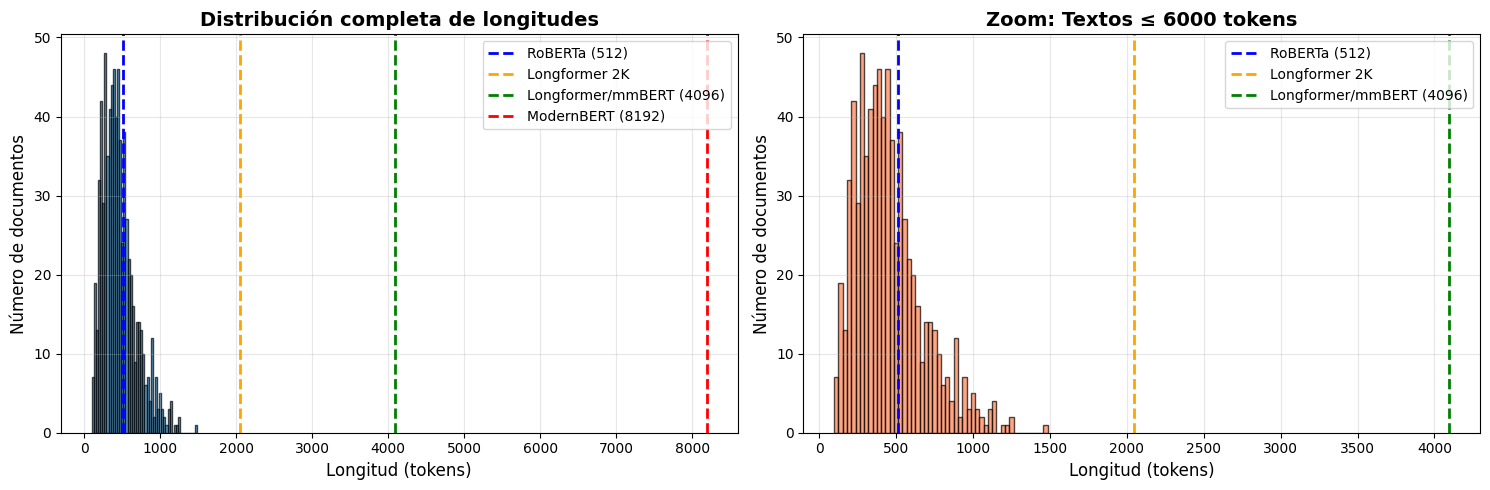


 RECOMENDACIÓN AUTOMÁTICA

 Situación actual:
   • 33.3% de textos > 512 tokens
   • 0.0% de textos > 2048 tokens
   • 0.0% de textos > 4096 tokens
   • Texto más largo: 1,486 tokens

 Recomendación basada en datos:

 USAR: Longformer/mmBERT (4096 tokens)
   Razón: 33.3% textos > 512, pero < 10% > 2048
   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)
   Opción A: Longformer español (corpus BNE)
   Opción B: mmBERT (multilingüe + 4096 tokens)

 CONFIGURACIONES RECOMENDADAS PARA TU DATASET:

 OPCIÓN 1 (Recomendada): mmBERT
   MMBERT_MAX_LENGTH = 4096
   Cobertura: 100.0%
   Ventaja: Textos largos + multilingüe

 OPCIÓN 2: Longformer español
   LONGFORMER_MAX_LENGTH = 2048  # Compromiso
   Cobertura: 100.0%
   Ventaja: Español corpus BNE

 OPCIÓN 3: RoBERTa + Sliding Window
   MAX_LENGTH = 512, OVERLAP = 128
   Cobertura: 100%
   Ventaja: Español médico específico


In [7]:
print(" ANÁLISIS DE LONGITUD DE TEXTOS\n")
print("="*70)

# ============================================================================
# CARGAR TOKENIZER (usamos RoBERTa como referencia)
# ============================================================================
from transformers import AutoTokenizer

print(" Cargando tokenizer (RoBERTa como referencia)...")
ref_tokenizer = AutoTokenizer.from_pretrained("PlanTL-GOB-ES/roberta-base-biomedical-clinical-es")
print(" Tokenizer cargado\n")

# ============================================================================
# ANALIZAR TODOS LOS DATASETS
# ============================================================================
print(" Analizando longitud de textos en TODOS los datasets...\n")

datasets_to_analyze = [
    ("Train", train_df),
    ("Dev", dev_df)
]

all_lengths = []
dataset_stats = {}

for dataset_name, df in datasets_to_analyze:
    print(f" Analizando {dataset_name} ({len(df)} documentos)...")

    lengths = []
    for text in tqdm(df['text'], desc=f"Tokenizando {dataset_name}"):
        if pd.notna(text):
            tokens = ref_tokenizer(
                str(text),
                truncation=False,  # No truncar para ver longitud real
                add_special_tokens=True
            )
            lengths.append(len(tokens['input_ids']))
        else:
            lengths.append(0)

    all_lengths.extend(lengths)
    dataset_stats[dataset_name] = lengths

    # Estadísticas por dataset
    print(f"   • Min: {min(lengths)} tokens")
    print(f"   • Max: {max(lengths)} tokens")
    print(f"   • Media: {np.mean(lengths):.1f} tokens")
    print(f"   • Mediana: {np.median(lengths):.1f} tokens")
    print()

# ============================================================================
# ESTADÍSTICAS GLOBALES
# ============================================================================
print("\n" + "="*70)
print(" ESTADÍSTICAS GLOBALES (TODOS LOS DATASETS)")
print("="*70)

total_docs = len(all_lengths)
min_length = min(all_lengths)
max_length = max(all_lengths)
mean_length = np.mean(all_lengths)
median_length = np.median(all_lengths)

print(f"\n Total documentos: {total_docs:,}")
print(f"\n Longitud en tokens:")
print(f"   • Mínima:    {min_length:,} tokens")
print(f"   • Máxima:    {max_length:,} tokens ")
print(f"   • Media:     {mean_length:,.1f} tokens")
print(f"   • Mediana:   {median_length:,.1f} tokens")

# Percentiles
print(f"\n Percentiles:")
for p in [50, 75, 90, 95, 99, 100]:
    value = np.percentile(all_lengths, p)
    print(f"   • P{p:2d}: {value:6.0f} tokens")

# ============================================================================
# ANÁLISIS POR VENTANAS DE MODELOS
# ============================================================================
print("\n" + "="*70)
print(" ANÁLISIS POR VENTANAS DE MODELOS")
print("="*70)

ventanas = [
    ("RoBERTa/mmBERT (baseline)", 512),
    ("Longformer/mmBERT", 2048),
    ("Longformer (full)", 4096),
    ("ModernBERT", 8192)
]

print(f"\n{'Modelo':<30} {'Ventana':<10} {'% Truncado':<12} {'Docs Truncados':<15}")
print("-"*70)

for modelo, ventana in ventanas:
    truncados = sum(1 for l in all_lengths if l > ventana)
    porcentaje = (truncados / total_docs) * 100

    status = "" if porcentaje < 5 else "" if porcentaje < 20 else ""

    print(f"{status} {modelo:<28} {ventana:<10} {porcentaje:>5.1f}%      {truncados:>6}/{total_docs}")

# ============================================================================
# DISTRIBUCIÓN VISUAL
# ============================================================================
print("\n" + "="*70)
print(" DISTRIBUCIÓN DE LONGITUDES")
print("="*70)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma completo
ax1.hist(all_lengths, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax1.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax1.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax1.axvline(8192, color='red', linestyle='--', linewidth=2, label='ModernBERT (8192)')
ax1.set_xlabel('Longitud (tokens)', fontsize=12)
ax1.set_ylabel('Número de documentos', fontsize=12)
ax1.set_title('Distribución completa de longitudes', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Zoom a textos < 6000 tokens (para ver mejor detalle)
lengths_filtered = [l for l in all_lengths if l <= 6000]
ax2.hist(lengths_filtered, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(512, color='blue', linestyle='--', linewidth=2, label='RoBERTa (512)')
ax2.axvline(2048, color='orange', linestyle='--', linewidth=2, label='Longformer 2K')
ax2.axvline(4096, color='green', linestyle='--', linewidth=2, label='Longformer/mmBERT (4096)')
ax2.set_xlabel('Longitud (tokens)', fontsize=12)
ax2.set_ylabel('Número de documentos', fontsize=12)
ax2.set_title('Zoom: Textos ≤ 6000 tokens', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# RECOMENDACIÓN AUTOMÁTICA
# ============================================================================
print("\n" + "="*70)
print(" RECOMENDACIÓN AUTOMÁTICA")
print("="*70)

truncados_512 = (sum(1 for l in all_lengths if l > 512) / total_docs) * 100
truncados_2048 = (sum(1 for l in all_lengths if l > 2048) / total_docs) * 100
truncados_4096 = (sum(1 for l in all_lengths if l > 4096) / total_docs) * 100

print(f"\n Situación actual:")
print(f"   • {truncados_512:.1f}% de textos > 512 tokens")
print(f"   • {truncados_2048:.1f}% de textos > 2048 tokens")
print(f"   • {truncados_4096:.1f}% de textos > 4096 tokens")
print(f"   • Texto más largo: {max_length:,} tokens")

print(f"\n Recomendación basada en datos:\n")

if truncados_512 < 5:
    print(" USAR: RoBERTa baseline (512 tokens)")
    print("   Razón: < 5% de textos truncados, pérdida mínima")
    print("   Ventajas: Más rápido, español médico específico")

elif truncados_512 < 20:
    print("  USAR: RoBERTa + Sliding Window")
    print(f"   Razón: {truncados_512:.1f}% de textos truncados (pérdida moderada)")
    print("   Ventajas: 100% cobertura, español médico, complejidad aceptable")

elif truncados_2048 < 10:
    print(" USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_512:.1f}% textos > 512, pero < 10% > 2048")
    print("   Configuración: MAX_LENGTH = 2048 (compromiso velocidad/cobertura)")
    print("   Opción A: Longformer español (corpus BNE)")
    print("   Opción B: mmBERT (multilingüe + 4096 tokens)")

elif truncados_4096 < 5:
    print(" USAR: Longformer/mmBERT (4096 tokens)")
    print(f"   Razón: {truncados_2048:.1f}% textos > 2048, casi ninguno > 4096")
    print("   Configuración: MAX_LENGTH = 4096 (cobertura completa)")
    print("   Preferir: mmBERT si hay mezcla de idiomas, Longformer si solo español")

else:
    print("  USAR: ModernBERT (8192 tokens)")
    print(f"   Razón: {truncados_4096:.1f}% textos > 4096 (necesitas ventana grande)")
    print("   Limitación: Solo inglés (considerar si es aceptable)")
    print("   Alternativa: RoBERTa + Sliding Window (español médico)")

print("\n" + "="*70)
print(f" CONFIGURACIONES RECOMENDADAS PARA TU DATASET:")
print("="*70)

if truncados_512 >= 20:
    if truncados_4096 < 5:
        print(f"\n OPCIÓN 1 (Recomendada): mmBERT")
        print(f"   MMBERT_MAX_LENGTH = 4096")
        print(f"   Cobertura: {100 - truncados_4096:.1f}%")
        print(f"   Ventaja: Textos largos + multilingüe")

        print(f"\n OPCIÓN 2: Longformer español")
        print(f"   LONGFORMER_MAX_LENGTH = 2048  # Compromiso")
        print(f"   Cobertura: {100 - truncados_2048:.1f}%")
        print(f"   Ventaja: Español corpus BNE")

        print(f"\n OPCIÓN 3: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico específico")
    else:
        print(f"\n OPCIÓN 1 (Recomendada): ModernBERT")
        print(f"   MODERNBERT_MAX_LENGTH = 8192")
        print(f"   Cobertura: ~100%")
        print(f"   Limitación: Solo inglés ")

        print(f"\n OPCIÓN 2: RoBERTa + Sliding Window")
        print(f"   MAX_LENGTH = 512, OVERLAP = 128, MAX_CHUNKS = 10")
        print(f"   Cobertura: 100%")
        print(f"   Ventaja: Español médico, sin límite de longitud")
else:
    print(f"\n Tu dataset tiene longitudes manejables")
    print(f"   RoBERTa baseline (512) cubre {100 - truncados_512:.1f}%")
    print(f"   Recomendación: Empezar con baseline, evaluar pérdida")

print("="*70)

## 5. Dataset y Modelo para Nivel 1 (Clasificador de Capítulos)

In [8]:
from torch.utils.data import Dataset, DataLoader

class ChapterDataset(Dataset):
    """Dataset para clasificación de capítulos CIE-10"""

    def __init__(self, df, tokenizer, chapter_to_idx=None, idx_to_chapter=None, max_length=512):
        self.texts = df['text'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Extraer capítulos de los códigos
        self.labels = []

        # Usar diccionarios globales si se proporcionan, sino crear locales
        if chapter_to_idx is not None and idx_to_chapter is not None:
            self.chapter_to_idx = chapter_to_idx
            self.idx_to_chapter = idx_to_chapter
        else:
            chapter_list = sorted(CIE10_CHAPTERS.keys())
            self.chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
            self.idx_to_chapter = {idx: ch for ch, idx in self.chapter_to_idx.items()}

        for codes_str in df['labels']:
            # Multi-label: un documento puede tener múltiples capítulos
            chapters = set()
            if pd.notna(codes_str):
                codes = [c.strip() for c in str(codes_str).split(';') if c.strip()]
                for code in codes:
                    chapter = extract_chapter_from_code(code)
                    if chapter and chapter in self.chapter_to_idx:
                        chapters.add(self.chapter_to_idx[chapter])

            # One-hot encoding multi-label
            label_vector = [0.0] * len(self.chapter_to_idx)
            for ch_idx in chapters:
                label_vector[ch_idx] = 1.0

            self.labels.append(label_vector)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(self.labels[idx])
        }


In [9]:
# ============================================================================
# CREAR DICCIONARIOS GLOBALES (para reutilizar en todos los modelos)
# ============================================================================
print(" Creando diccionarios de capítulos globales...")

chapter_list = sorted(CIE10_CHAPTERS.keys())
chapter_to_idx = {ch: idx for idx, ch in enumerate(chapter_list)}
idx_to_chapter = {idx: ch for ch, idx in chapter_to_idx.items()}

print(f" Diccionarios creados: {len(chapter_to_idx)} capítulos")
print(f"   Ejemplo: {list(chapter_to_idx.items())[:3]}")
print(f"\n Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)")
print("="*70)

 Creando diccionarios de capítulos globales...
 Diccionarios creados: 20 capítulos
   Ejemplo: [('A', 0), ('C', 1), ('D', 2)]

 Estos diccionarios se reutilizarán en todos los modelos (RoBERTa, Longformer, mmBERT, ModernBERT)


In [10]:
import torch.nn as nn
from transformers import AutoModel

class ChapterClassifier(nn.Module):
    """Clasificador de Capítulos CIE-10 (Nivel 1)"""

    def __init__(self, model_name, num_chapters, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_chapters)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Usar [CLS] token
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits

print(f" ChapterClassifier definido")

 ChapterClassifier definido


In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

def train_epoch(model, dataloader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > threshold).float()

            all_preds.append(preds)
            all_labels.append(labels)

    all_preds = torch.cat(all_preds).float().numpy()
    all_labels = torch.cat(all_labels).float().numpy()

    # Métricas micro/macro
    f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_labels, all_preds, average='micro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)

    return {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'precision': precision,
        'recall': recall
    }

print(" Funciones de entrenamiento definidas")

 Funciones de entrenamiento definidas


In [12]:
# ============================================================================
# FUNCIONES HELPER PARA TRACKING Y VISUALIZACIÓN
# ============================================================================
import time
from datetime import datetime

def create_training_history(model_name, learning_rate, batch_size, max_length):
    """Crea estructura para guardar historial de entrenamiento con metadata"""
    return {
        # Metadata del modelo
        'model_name': model_name,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'max_length': max_length,
        'start_time': datetime.now().isoformat(),

        # Métricas por época
        'epochs': [],
        'train_loss': [],
        'dev_f1_micro': [],
        'dev_f1_macro': [],
        'dev_precision': [],
        'dev_recall': [],
        'learning_rates': [],  # LR en cada época (puede cambiar con scheduler)
        'epoch_time_seconds': [],  # Tiempo por época
        'cumulative_time_seconds': [],  # Tiempo acumulado

        # Mejor resultado
        'best_epoch': 0,
        'best_f1_micro': 0.0
    }

def update_history(history, epoch, train_loss, metrics, learning_rate, epoch_time):
    """Actualiza el historial con métricas de una época"""
    history['epochs'].append(epoch)
    history['train_loss'].append(float(train_loss))
    history['dev_f1_micro'].append(float(metrics['f1_micro']))
    history['dev_f1_macro'].append(float(metrics['f1_macro']))
    history['dev_precision'].append(float(metrics['precision']))
    history['dev_recall'].append(float(metrics['recall']))
    history['learning_rates'].append(float(learning_rate))
    history['epoch_time_seconds'].append(float(epoch_time))

    # Tiempo acumulado
    if history['cumulative_time_seconds']:
        cumulative = history['cumulative_time_seconds'][-1] + epoch_time
    else:
        cumulative = epoch_time
    history['cumulative_time_seconds'].append(float(cumulative))

def save_history(history, base_path):
    """Guarda historial a JSON y CSV"""
    # Agregar tiempo final
    history['end_time'] = datetime.now().isoformat()
    history['total_time_seconds'] = sum(history['epoch_time_seconds'])

    # Guardar JSON completo
    json_path = base_path.parent / f"{base_path.stem}.json"
    with open(json_path, 'w') as f:
        json.dump(history, f, indent=2)

    # Guardar CSV (solo métricas por época)
    csv_path = base_path.parent / f"{base_path.stem}.csv"
    df = pd.DataFrame({
        'epoch': history['epochs'],
        'train_loss': history['train_loss'],
        'dev_f1_micro': history['dev_f1_micro'],
        'dev_f1_macro': history['dev_f1_macro'],
        'dev_precision': history['dev_precision'],
        'dev_recall': history['dev_recall'],
        'learning_rate': history['learning_rates'],
        'epoch_time_sec': history['epoch_time_seconds'],
        'cumulative_time_sec': history['cumulative_time_seconds']
    })
    df.to_csv(csv_path, index=False, float_format='%.6f')

    print(f" Historial guardado:")
    print(f"    JSON: {json_path}")
    print(f"    CSV: {csv_path}")

def visualize_training(history, title, save_path):
    """Crea visualización completa del entrenamiento"""
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'{title} - Resultados del Entrenamiento', fontsize=16, fontweight='bold')

    epochs = history['epochs']

    # Panel 1: Train Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'r-', linewidth=2, marker='o')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Pérdida de Entrenamiento')
    axes[0, 0].grid(True, alpha=0.3)
    min_loss_idx = np.argmin(history['train_loss'])
    min_loss = history['train_loss'][min_loss_idx]
    axes[0, 0].annotate(f'Mín: {min_loss:.4f}',
                        xy=(epochs[min_loss_idx], min_loss),
                        xytext=(10, 10), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='yellow', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='red'))

    # Panel 2: F1 Scores
    axes[0, 1].plot(epochs, history['dev_f1_micro'], 'b-', linewidth=2, marker='s', label='F1 Micro')
    axes[0, 1].plot(epochs, history['dev_f1_macro'], 'g-', linewidth=2, marker='^', label='F1 Macro')
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Micro vs Macro')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    best_idx = np.argmax(history['dev_f1_micro'])
    best_f1 = history['dev_f1_micro'][best_idx]
    axes[0, 1].annotate(f'Mejor: {best_f1:.4f}',
                        xy=(epochs[best_idx], best_f1),
                        xytext=(10, -20), textcoords='offset points',
                        bbox=dict(boxstyle='round', fc='lightblue', alpha=0.7),
                        arrowprops=dict(arrowstyle='->', color='blue'))

    # Panel 3: Precision vs Recall
    axes[0, 2].plot(epochs, history['dev_precision'], 'purple', linewidth=2, marker='D', label='Precisión')
    axes[0, 2].plot(epochs, history['dev_recall'], 'orange', linewidth=2, marker='v', label='Recall')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Precisión vs Recall')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Panel 4: Learning Rate
    axes[1, 0].plot(epochs, history['learning_rates'], 'brown', linewidth=2, marker='x')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Panel 5: Tiempo por Época
    axes[1, 1].bar(epochs, [t/60 for t in history['epoch_time_seconds']], color='teal', alpha=0.7)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Tiempo (minutos)')
    axes[1, 1].set_title('Tiempo por Época')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    # Panel 6: Best Model Summary
    best_idx = np.argmax(history['dev_f1_micro'])
    total_time_min = sum(history['epoch_time_seconds']) / 60
    avg_time_min = np.mean(history['epoch_time_seconds']) / 60

    summary_text = f"""
MEJOR MODELO
══════════════════════════════════
Modelo:       {history['model_name'][:30]}
LR Inicial:   {history['learning_rate']:.2e}
Batch Size:   {history['batch_size']}
Max Length:   {history['max_length']}
──────────────────────────────────
Mejor Época:  {epochs[best_idx]}
Train Loss:   {history['train_loss'][best_idx]:.4f}
F1 Micro:     {history['dev_f1_micro'][best_idx]:.4f}
F1 Macro:     {history['dev_f1_macro'][best_idx]:.4f}
Precisión:    {history['dev_precision'][best_idx]:.4f}
Recall:       {history['dev_recall'][best_idx]:.4f}
LR:           {history['learning_rates'][best_idx]:.2e}
──────────────────────────────────
Tiempo total: {total_time_min:.1f} min
Tiempo/época: {avg_time_min:.1f} min
══════════════════════════════════
"""
    axes[1, 2].text(0.5, 0.5, summary_text,
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].axis('off')
    axes[1, 2].set_title('Resumen del Mejor Modelo')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla con todas las épocas
    df_history = pd.DataFrame({
        'Época': epochs,
        'Train Loss': history['train_loss'],
        'F1 Micro': history['dev_f1_micro'],
        'F1 Macro': history['dev_f1_macro'],
        'Precisión': history['dev_precision'],
        'Recall': history['dev_recall'],
        'LR': history['learning_rates'],
        'Tiempo (min)': [t/60 for t in history['epoch_time_seconds']]
    })
    df_history[''] = ''
    df_history.loc[best_idx, ''] = ''

    print("\n Historial Completo de Entrenamiento:\n")
    print(df_history.to_string(index=False))
    print(f"\n Mejor época: {epochs[best_idx]} con F1 Micro = {history['dev_f1_micro'][best_idx]:.4f}")
    print(f"⏱  Tiempo total: {total_time_min:.1f} minutos ({total_time_min/60:.2f} horas)")

    return df_history

print(" Funciones de visualización definidas")

 Funciones de visualización definidas


In [13]:
# ============================================================================
# FUNCIÓN HELPER: VISUALIZACIÓN CON COMPARACIÓN
# ============================================================================

def visualize_and_compare(training_history, model_name_short, save_prefix):
    """
    Visualiza el entrenamiento actual y compara con anteriores

    Args:
        training_history: Historial del entrenamiento actual
        model_name_short: Nombre corto para el título (ej: "RoBERTa Baseline")
        save_prefix: Prefijo para los archivos (ej: "roberta_baseline")
    """
    # Visualizar entrenamiento actual
    visualize_training(
        history=training_history,
        title=f"{model_name_short} (Nivel 1 - Capítulos)",
        save_path=config.LEVEL1_DIR / f"training_curves_{save_prefix}.png"
    )

    # Comparación con entrenamientos anteriores
    if len(all_training_histories) > 1:
        print("\n" + "="*70)
        print(" COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS")
        print("="*70 + "\n")

        # Crear tabla comparativa
        comparison_data = []
        for i, hist in enumerate(all_training_histories, 1):
            best_idx = np.argmax(hist['dev_f1_micro'])
            comparison_data.append({
                'Entrenamiento': i,
                'Modelo': hist['model_name'][:40],
                'Mejor Época': hist['epochs'][best_idx],
                'F1 Micro': hist['dev_f1_micro'][best_idx],
                'F1 Macro': hist['dev_f1_macro'][best_idx],
                'Precision': hist['dev_precision'][best_idx],
                'Recall': hist['dev_recall'][best_idx],
                'Tiempo (min)': sum(hist['epoch_time_seconds'])/60
            })

        df_comparison = pd.DataFrame(comparison_data)

        # Marcar el mejor
        best_model_idx = df_comparison['F1 Micro'].idxmax()
        df_comparison[''] = ''
        df_comparison.loc[best_model_idx, ''] = ''

        print(df_comparison.to_string(index=False))

        # Gráfica comparativa
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))

        # Panel 1: Evolución de F1 Micro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 0].plot(hist['epochs'], hist['dev_f1_micro'],
                        marker='o', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 0].set_xlabel('Época', fontsize=12)
        axes[0, 0].set_ylabel('F1 Micro', fontsize=12)
        axes[0, 0].set_title('Comparación: F1 Micro por Época', fontsize=14, fontweight='bold')
        axes[0, 0].legend(loc='best', fontsize=9)
        axes[0, 0].grid(True, alpha=0.3)

        # Panel 2: Evolución de F1 Macro
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[0, 1].plot(hist['epochs'], hist['dev_f1_macro'],
                        marker='s', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[0, 1].set_xlabel('Época', fontsize=12)
        axes[0, 1].set_ylabel('F1 Macro', fontsize=12)
        axes[0, 1].set_title('Comparación: F1 Macro por Época', fontsize=14, fontweight='bold')
        axes[0, 1].legend(loc='best', fontsize=9)
        axes[0, 1].grid(True, alpha=0.3)

        # Panel 3: Train Loss
        for i, hist in enumerate(all_training_histories, 1):
            model_name = hist['model_name'].split(' - ')[0][:25]
            axes[1, 0].plot(hist['epochs'], hist['train_loss'],
                        marker='^', linewidth=2, label=f"{i}. {model_name}", alpha=0.8)
        axes[1, 0].set_xlabel('Época', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Comparación: Train Loss por Época', fontsize=14, fontweight='bold')
        axes[1, 0].legend(loc='best', fontsize=9)
        axes[1, 0].grid(True, alpha=0.3)

        # Panel 4: Comparación de mejores métricas
        x = np.arange(len(all_training_histories))
        width = 0.2

        f1_micros = [max(h['dev_f1_micro']) for h in all_training_histories]
        f1_macros = [max(h['dev_f1_macro']) for h in all_training_histories]
        precisions = [max(h['dev_precision']) for h in all_training_histories]
        recalls = [max(h['dev_recall']) for h in all_training_histories]

        axes[1, 1].bar(x - 1.5*width, f1_micros, width, label='F1 Micro', alpha=0.8)
        axes[1, 1].bar(x - 0.5*width, f1_macros, width, label='F1 Macro', alpha=0.8)
        axes[1, 1].bar(x + 0.5*width, precisions, width, label='Precision', alpha=0.8)
        axes[1, 1].bar(x + 1.5*width, recalls, width, label='Recall', alpha=0.8)

        axes[1, 1].set_xlabel('Entrenamiento', fontsize=12)
        axes[1, 1].set_ylabel('Score', fontsize=12)
        axes[1, 1].set_title('Comparación: Mejores Métricas', fontsize=14, fontweight='bold')
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels([f"#{i+1}" for i in range(len(all_training_histories))])
        axes[1, 1].legend(loc='best')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].set_ylim([0, 1.0])

        plt.tight_layout()
        plt.savefig(config.LEVEL1_DIR / "comparison_all_trainings.png", dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n Mejor modelo hasta ahora: Entrenamiento #{best_model_idx + 1}")
        print(f"   Modelo: {all_training_histories[best_model_idx]['model_name'][:50]}")
        print(f"   F1 Micro: {df_comparison.loc[best_model_idx, 'F1 Micro']:.4f}")
        print(f"   F1 Macro: {df_comparison.loc[best_model_idx, 'F1 Macro']:.4f}")
        print(f"   Tiempo total: {df_comparison.loc[best_model_idx, 'Tiempo (min)']:.1f} minutos")
    else:
        print("\n Este es el primer entrenamiento. Las comparaciones aparecerán después del segundo.")

print(" Función de visualización con comparación definida")

 Función de visualización con comparación definida


##  Entendiendo las Métricas de Evaluación

### **F1 Micro vs F1 Macro**

Cuando entrenas modelos multi-label (como este clasificador de capítulos CIE-10), verás dos tipos de F1:

#### **F1 Micro: Agregación Global**
```
F1 Micro = 2 × (Precision_global × Recall_global) / (Precision_global + Recall_global)
```
- **Cómo se calcula:** Suma todos los TP, FP, FN de todas las clases y calcula F1 global
- **Qué mide:** Rendimiento general considerando **todas las predicciones por igual**
- **Característica:** **Favorece a las clases frecuentes** (tienen más muestras)
- **Ejemplo:** Si tienes 1000 casos del capítulo I (circulatorio) y 10 del capítulo O (embarazo), el capítulo I domina la métrica

#### **F1 Macro: Promedio de Clases**
```
F1 Macro = (F1_clase1 + F1_clase2 + ... + F1_claseN) / N
```
- **Cómo se calcula:** Calcula F1 de cada clase individualmente, luego promedia
- **Qué mide:** Rendimiento **dando igual peso a cada clase**
- **Característica:** **Penaliza el mal desempeño en clases raras**
- **Ejemplo:** Si fallas en el capítulo O (embarazo), afecta igual que fallar en el capítulo I (circulatorio)

---

### ** ¿Por qué Micro sube y Macro baja?**

**Esto indica desbalance de clases:**

| Métrica | Sube  | Baja  | Interpretación |
|---------|--------|---------|----------------|
| **F1 Micro** |  | | El modelo mejora en **capítulos frecuentes** (I, J, K, S...) |
| **F1 Macro** | |  | El modelo empeora en **capítulos raros** (O, P, Q, Z...) |

**¿Qué está pasando?**
1. El modelo aprende primero las clases frecuentes (más ejemplos = más gradiente)
2. Se "olvida" de las clases raras para optimizar loss global
3. F1 Micro mejora (por clases frecuentes) pero F1 Macro baja (por clases raras)

**Analogía:**
```
Estudiante que:
 Saca 95% en las 3 materias principales     → F1 Micro sube
 Saca 20% en las 18 materias optativas      → F1 Macro baja

Promedio ponderado: Alto (90%)
Promedio simple: Bajo (30%)
```

---

### ** Otras Métricas**

#### **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- **Qué mide:** De lo que predijo, ¿cuánto fue correcto?
- **Ejemplo:** Si predijo 100 capítulos y 45 eran correctos → Precision = 0.45
- **Trade-off:** Alta precision → pocos falsos positivos, pero puede perder casos reales

#### **Recall (Exhaustividad)**
```
Recall = TP / (TP + FN)
```
- **Qué mide:** De lo que debía encontrar, ¿cuánto encontró?
- **Ejemplo:** Si había 100 capítulos correctos y encontró 50 → Recall = 0.50
- **Trade-off:** Alto recall → encuentra casi todo, pero puede tener muchos falsos positivos

---

### ** ¿Qué es un buen resultado?**

**En épocas tempranas (1-5):**
- F1 Micro 0.40-0.60 → Normal 
- F1 Macro 0.10-0.30 → Esperado (aprende primero clases frecuentes)
- Precision ≈ Recall → Balanced

**Al final del entrenamiento (20-30):**
- F1 Micro > 0.70 → Bueno 
- F1 Macro > 0.50 → Bueno (aprende también clases raras)
- Si Macro sigue bajo → Considerar class weights o data augmentation

**Para producción en CIE-10:**
- **Nivel 1 (capítulos):** F1 Micro > 0.75 es aceptable
- **Nivel 2 (códigos):** F1 Micro > 0.60 es realista (tarea muy difícil)
- **Sistema jerárquico completo:** F1@10 > 0.50 (top-10 códigos correctos)

##  Primer intento - modelo RoBERTa base, del BSC, entrenado con datos clínicos

In [14]:
print(" Iniciando entrenamiento Nivel 1: Clasificador de Capítulos\n")

# Inicializar tokenizer
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)

# Crear datasets
print(" Creando datasets...")
train_dataset = ChapterDataset(train_df, tokenizer, config.MAX_LENGTH)
dev_dataset = ChapterDataset(dev_df, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=True,
    num_workers=Config.NUM_WORKERS
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=config.BATCH_SIZE_LEVEL1,
    shuffle=False,
    num_workers=Config.NUM_WORKERS
)

num_chapters = len(train_dataset.chapter_to_idx)
print(f" Datasets creados: {len(train_dataset)} train, {len(dev_dataset)} dev")
print(f" Número de capítulos: {num_chapters}")

# Inicializar modelo
print(f"\n Cargando modelo: {config.MODEL_NAME}")
model = ChapterClassifier(config.MODEL_NAME, num_chapters, config.DROPOUT)
model.to(device)

# Optimizer y criterion
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=0.01)
criterion = nn.BCEWithLogitsLoss()

# Scheduler con warmup
total_steps = len(train_loader) * config.EPOCHS_LEVEL1
warmup_steps = int(total_steps * config.WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f" Parámetros: LR={config.LEARNING_RATE}, Epochs={config.EPOCHS_LEVEL1}, Batch={config.BATCH_SIZE_LEVEL1}")
print(f" Scheduler: {warmup_steps} warmup steps de {total_steps} total")
print(f" Early Stopping: patience={config.EARLY_STOPPING_PATIENCE} épocas")
print(f" Modelo inicializado en {device}")

 Iniciando entrenamiento Nivel 1: Clasificador de Capítulos



 Creando datasets...
 Datasets creados: 500 train, 250 dev
 Número de capítulos: 20

 Cargando modelo: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: PlanTL-GOB-ES/roberta-base-biomedical-clinical-es
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Parámetros: LR=3e-05, Epochs=200, Batch=8
 Scheduler: 1260 warmup steps de 12600 total
 Early Stopping: patience=40 épocas
 Modelo inicializado en cuda


In [15]:
# ============================================================================
# HISTORIAL GLOBAL DE ENTRENAMIENTOS (Para comparaciones)
# ============================================================================
if 'all_training_histories' not in globals():
    all_training_histories = []

print(" Sistema de historial inicializado")
print(f" Número de entrenamientos previos: {len(all_training_histories)}")

 Sistema de historial inicializado
 Número de entrenamientos previos: 0


##  Sistema de Historial y Comparación de Entrenamientos

### **¿Qué hace este sistema?**

Este notebook ahora incluye un **sistema automático de tracking y comparación** que:

1. ** Guarda el historial completo** de cada entrenamiento:
   - Métricas por época (F1 Micro, F1 Macro, Precision, Recall, Loss)
   - Tiempos de entrenamiento
   - Configuración del modelo (learning rate, batch size, max length)
   - Mejor época y mejor F1 alcanzado

2. ** Visualiza automáticamente** después de cada entrenamiento:
   - Curvas de aprendizaje (Loss, F1, Precision, Recall)
   - Learning rate schedule
   - Tiempo por época
   - Resumen del mejor modelo

3. ** Compara automáticamente** con entrenamientos anteriores:
   - Tabla comparativa de todos los entrenamientos
   - Gráficas superpuestas de evolución de métricas
   - Identificación del mejor modelo hasta el momento

### **Entrenamientos con historial implementado:**

 **1. RoBERTa Baseline** (512 tokens, español médico)  
 **2. RoBERTa + Class Weights** (balance de clases)  
 **3. RoBERTa + Class Weights + sliding windows** (balance de clases + ventanas con overlap)  
 **4. Longformer** (4096 tokens, textos largos)  
 **5. mmBERT** (4096 tokens, multilingüe)  

### **¿Cómo funciona?**

```python
# 1. Al inicio del notebook, se inicializa la lista global
all_training_histories = []

# 2. Cada entrenamiento crea su historial
training_history = create_training_history(
    model_name="RoBERTa Baseline",
    learning_rate=3e-5,
    batch_size=16,
    max_length=512
)

# 3. Durante el entrenamiento, se actualiza el historial
update_history(training_history, epoch, train_loss, metrics, lr, time)

# 4. Al finalizar, se guarda y se añade a la lista global
save_history(training_history, model_path)  # Guarda JSON + CSV
all_training_histories.append(training_history)

# 5. Se visualiza y compara automáticamente
visualize_and_compare(training_history, "RoBERTa Baseline", "roberta_baseline")
```

### **Archivos generados**

Para cada entrenamiento, se generan 4 archivos:

```
snapshots/nivel1_capitulos/
├── best_model_roberta_baseline.pt       # Pesos del modelo
├── best_model_roberta_baseline.json     # Historial completo (legible)
├── best_model_roberta_baseline.csv      # Métricas por época (Excel)
└── training_curves_roberta_baseline.png # Visualización individual

# Archivo de comparación global (actualizado tras cada entrenamiento)
└── comparison_all_trainings.png          # Comparación de todos
```

### **Visualizaciones generadas**

**Individual (por entrenamiento):**
- Panel 1: Train Loss por época
- Panel 2: F1 Micro vs F1 Macro por época
- Panel 3: Precision vs Recall por época
- Panel 4: Learning Rate schedule
- Panel 5: Tiempo por época
- Panel 6: Resumen del mejor modelo

**Comparativa (todos los entrenamientos):**
- Panel 1: F1 Micro superpuesto
- Panel 2: F1 Macro superpuesto
- Panel 3: Train Loss superpuesto
- Panel 4: Gráfica de barras de mejores métricas
- Tabla comparativa con  marcando el mejor

### **Ventajas**

 **Reproducibilidad:** Toda la configuración queda guardada  
 **Análisis posterior:** Datos en CSV para Excel/Pandas  
 **Comparación visual:** Gráficas automáticas actualizadas  
 **Tracking automático:** No necesitas código extra en cada entrenamiento  
 **Identificación del mejor:** Marca automáticamente el modelo ganador  
 **Historial persistente:** La lista `all_training_histories` se mantiene en memoria

### **Ejemplo de salida de comparación:**

```
 COMPARACIÓN CON TODOS LOS ENTRENAMIENTOS
══════════════════════════════════════════════════════════════════════

 Entrenamiento  Modelo                            Mejor Época  F1 Micro  F1 Macro  ...     
────────────────────────────────────────────────────────────────────────────────────────────
 1              RoBERTa Baseline (Nivel 1) - ...  15           0.7542    0.4521    ...  
 2              RoBERTa con Class Weights (N...   18           0.7201    0.5834    ...     
 3              Longformer (Nivel 1) - allenai    12           0.7689    0.4892    ...     
 4              mmBERT (Nivel 1) - jhu-clsp/m...  20           0.7423    0.5123    ...     

 Mejor modelo hasta ahora: Entrenamiento #3
   Modelo: Longformer (Nivel 1) - allenai/longformer-base-4096
   F1 Micro: 0.7689
   F1 Macro: 0.4892
   Tiempo total: 45.3 minutos
```

### **Uso en entrenamientos futuros**

Para añadir un nuevo modelo (ej: ModernBERT), solo necesitas seguir el patrón:

```python
# 1. Crear historial
training_history_modernbert = create_training_history(
    model_name=f"ModernBERT (Nivel 1) - {MODEL}",
    learning_rate=config.LEARNING_RATE,
    batch_size=config.BATCH_SIZE_LEVEL1,
    max_length=8192
)

# 2. En el loop de entrenamiento
for epoch in range(config.EPOCHS_LEVEL1):
    epoch_start_time = time.time()
    
    # ... entrenamiento y evaluación ...
    
    epoch_time = time.time() - epoch_start_time
    current_lr = optimizer.param_groups[0]['lr']
    
    # Actualizar historial
    update_history(training_history_modernbert, epoch + 1, 
                   train_loss, metrics, current_lr, epoch_time)
    
    # Early stopping con historial
    if metrics['f1_micro'] > best_f1:
        training_history_modernbert['best_epoch'] = epoch + 1
        training_history_modernbert['best_f1_micro'] = metrics['f1_micro']

# 3. Al finalizar
save_history(training_history_modernbert, model_path)
all_training_histories.append(training_history_modernbert)

# 4. Visualizar y comparar
visualize_and_compare(training_history_modernbert, "ModernBERT", "modernbert")
```

¡El sistema hace el resto automáticamente! 

## Primer Entrenamiénto: Modelo RoBERTa, entrenado con textos clínicos en el BSC

In [16]:
import gc

# Mover a CPU todo modulo que siga vivo: quitarlo de globals() no libera la VRAM porque
# IPython conserva referencias en su historial de salidas (_, __, Out[...]).
for _o in gc.get_objects():
    # El try cubre tambien el isinstance: entre los objetos vivos hay weakrefs ya muertos
    # que lanzan ReferenceError al mirarlos.
    try:
        if isinstance(_o, torch.nn.Module):
            _o.to("cpu")
        elif isinstance(_o, torch.optim.Optimizer):
            _o.state.clear()
    except Exception:
        pass
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM ocupada tras limpiar: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

print(" SEXTO INTENTO: ModernBERT (Nueva Generación)\n")
print("="*70)

# ============================================================================
# CONFIGURACIÓN
# ============================================================================
MODERNBERT_MODEL = "answerdotai/ModernBERT-base"  # Estado del arte 2024
MODERNBERT_MAX_LENGTH = Config.MODERNBERT_MAX_LENGTH  # ¡16× más que RoBERTa!

print(f"  Configuración ModernBERT:")
print(f"   Modelo: {MODERNBERT_MODEL}")
print(f"   Max Length: {MODERNBERT_MAX_LENGTH} tokens (16× RoBERTa!)")
print(f"   Batch Size: {config.BATCH_SIZE_LEVEL1 // 4} (reducido por longitud)")
print(f"   Idioma: Inglés (limitación actual)")
print(f"   Arquitectura: Flash Attention 2.0 + RoPE + GeGLU")
print()

# ============================================================================
# VERIFICAR DISPONIBILIDAD
# ============================================================================
print(" Verificando disponibilidad de ModernBERT...\n")

try:
    modernbert_tokenizer = AutoTokenizer.from_pretrained(MODERNBERT_MODEL)
    modernbert_available = True
    print(" ModernBERT disponible")
except Exception as e:
    modernbert_available = False
    print(f" ModernBERT no disponible: {e}")
    print("   Puede que el modelo sea muy nuevo o requiera transformers >= 4.36")
    print("   Instala: pip install -U transformers accelerate")

if not modernbert_available:
    print("\n  Saltando entrenamiento con ModernBERT")
    print("="*70)
else:
    # ========================================================================
    # TOKENIZER
    # ========================================================================
    print(" Tokenizer ModernBERT cargado")
    print()

    # ========================================================================
    # DATASET (con 8192 tokens)
    # ========================================================================
    print(" Creando datasets ModernBERT (8192 tokens)...")

    modernbert_train_dataset = ChapterDataset(
        train_df,
        modernbert_tokenizer,
        chapter_to_idx,  # Usar diccionario global
        idx_to_chapter,  # Usar diccionario global
        max_length=MODERNBERT_MAX_LENGTH
    )

    modernbert_dev_dataset = ChapterDataset(
        dev_df,
        modernbert_tokenizer,
        chapter_to_idx,  # Usar diccionario global
        idx_to_chapter,  # Usar diccionario global
        max_length=MODERNBERT_MAX_LENGTH
    )

    # Batch size reducido por longitud de secuencia
    modernbert_batch_size = max(1, config.BATCH_SIZE_LEVEL1 // 4)

    modernbert_train_loader = DataLoader(
        modernbert_train_dataset,
        batch_size=modernbert_batch_size,
        shuffle=True
    )

    modernbert_dev_loader = DataLoader(
        modernbert_dev_dataset,
        batch_size=modernbert_batch_size,
        shuffle=False
    )

    print(f"   Train samples: {len(modernbert_train_dataset)}")
    print(f"   Dev samples: {len(modernbert_dev_dataset)}")
    print(f"   Batch size ajustado: {modernbert_batch_size}")
    print()

    # ========================================================================
    # MODELO
    # ========================================================================
    print(" Cargando modelo ModernBERT...")
    modernbert_model = ChapterClassifier(
        model_name=MODERNBERT_MODEL,
        num_chapters=len(chapter_to_idx)
    ).to(device)

    print(f" Modelo cargado: {sum(p.numel() for p in modernbert_model.parameters()):,} parámetros")
    print()

    # ========================================================================
    # ENTRENAMIENTO
    # ========================================================================
    print(" Iniciando entrenamiento ModernBERT...")
    print("="*70)

    modernbert_optimizer = torch.optim.AdamW(modernbert_model.parameters(), lr=config.LEARNING_RATE)
    modernbert_criterion = nn.BCEWithLogitsLoss()

    best_f1_modernbert = 0.0
    best_modernbert_model_path = config.LEVEL1_DIR / "best_model_modernbert.pth"
    epochs_without_improvement_modernbert = 0

    for epoch in range(config.EPOCHS_LEVEL1):
        print(f"\n Época {epoch+1}/{config.EPOCHS_LEVEL1}")
        print("-"*70)

        # Entrenar
        modernbert_model.train()
        train_loss = 0.0

        train_pbar = tqdm(modernbert_train_loader, desc="Entrenando")
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            modernbert_optimizer.zero_grad()
            logits = modernbert_model(input_ids, attention_mask)
            loss = modernbert_criterion(logits, labels)
            loss.backward()
            modernbert_optimizer.step()

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = train_loss / len(modernbert_train_loader)

        # Evaluar
        modernbert_model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            eval_pbar = tqdm(modernbert_dev_loader, desc="Evaluando")
            for batch in eval_pbar:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = modernbert_model(input_ids, attention_mask)
                preds = (torch.sigmoid(logits) > config.THRESHOLD_LEVEL1).float()

                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        all_preds = torch.cat(all_preds).float().numpy()
        all_labels = torch.cat(all_labels).float().numpy()

        # Métricas
        f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        print(f"\n Resultados Época {epoch+1}:")
        print(f"   Loss: {avg_train_loss:.4f}")
        print(f"   F1 Micro: {f1_micro:.4f}")
        print(f"   F1 Macro: {f1_macro:.4f}")

        # Guardar mejor modelo
        if f1_micro > best_f1_modernbert:
            best_f1_modernbert = f1_micro
            epochs_without_improvement_modernbert = 0

            torch.save({
                'model_state_dict': modernbert_model.state_dict(),
                'f1_micro': best_f1_modernbert,
                'f1_macro': f1_macro,
                'chapter_to_idx': modernbert_train_dataset.chapter_to_idx,
                'idx_to_chapter': modernbert_train_dataset.idx_to_chapter,
                'max_length': MODERNBERT_MAX_LENGTH
            }, best_modernbert_model_path)
            print(f"    Mejor modelo guardado! F1={best_f1_modernbert:.4f}")
        else:
            epochs_without_improvement_modernbert += 1
            if epochs_without_improvement_modernbert >= config.EARLY_STOPPING_PATIENCE:
                print(f"    Early stopping: sin mejora en {config.EARLY_STOPPING_PATIENCE} épocas")
                break

    print(f"\n Entrenamiento con ModernBERT completado!")
    print(f" Mejor F1 Micro: {best_f1_modernbert:.4f}")
    print(f" Modelo guardado: {best_modernbert_model_path}")

    print("\n" + "="*70)
    print(" COMPARACIÓN COMPLETA DE MODELOS")
    print("="*70)
    print("\n¿Cuál modelo elegir? Depende de tus prioridades:\n")

    print("1⃣  RoBERTa Médico (baseline):")
    print("   • Velocidad: ")
    print("   • Max tokens: 512 (trunca 33%)")
    print("   • Español médico: ")
    print("   • Uso: Baseline rápido\n")

    print("2⃣  RoBERTa + Sliding Window:")
    print("   • Velocidad: ")
    print("   • Max tokens: Ilimitado (chunking)")
    print("   • Español médico: ")
    print("   • Uso: Mejor balance (RECOMENDADO) \n")

    print("3⃣  Longformer Español:")
    print("   • Velocidad: ")
    print("   • Max tokens: 4096")
    print("   • Español general: ")
    print("   • Uso: Alternativa sin chunking\n")

    print("4⃣  mmBERT (Modern Multilingual):")
    print("   • Velocidad: ")
    print("   • Max tokens: 4096 (como Longformer)")
    print("   • Multilingüe:  (100+ idiomas)")
    print("   • Uso: Textos largos + multilingüe \n")

    print("5⃣  ModernBERT:")
    print("   • Velocidad:  (3× BERT)")
    print("   • Max tokens: 8192 (¡16× RoBERTa!)")
    print("   • Solo inglés: ")
    print("   • Uso: Experimentación/futuro\n")

    print("="*70)
    print(" RECOMENDACIÓN FINAL:")
    print("   Producción      → RoBERTa español + Sliding Window ")
    print("   Textos largos   → mmBERT (4096 tokens + multilingüe)")
    print("   Velocidad       → ModernBERT (si inglés aceptable)")
    print("   Simplicidad     → Longformer español")
    print("="*70)

VRAM ocupada tras limpiar: 0.00 GB
 SEXTO INTENTO: ModernBERT (Nueva Generación)

  Configuración ModernBERT:
   Modelo: answerdotai/ModernBERT-base
   Max Length: 1500 tokens (16× RoBERTa!)
   Batch Size: 2 (reducido por longitud)
   Idioma: Inglés (limitación actual)
   Arquitectura: Flash Attention 2.0 + RoPE + GeGLU

 Verificando disponibilidad de ModernBERT...



 ModernBERT disponible
 Tokenizer ModernBERT cargado

 Creando datasets ModernBERT (8192 tokens)...
   Train samples: 500
   Dev samples: 250
   Batch size ajustado: 2

 Cargando modelo ModernBERT...


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", dtype=torch.float16)`


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Evaluando:   0%|          | 0/125 [00:00<?, ?it/s]


 Resultados Época 64:
   Loss: 0.0012
   F1 Micro: 0.6163
   F1 Macro: 0.4569

 Época 65/200
----------------------------------------------------------------------


Entrenando:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluando:   0%|          | 0/125 [00:00<?, ?it/s]


 Resultados Época 65:
   Loss: 0.0011
   F1 Micro: 0.6165
   F1 Macro: 0.4570
    Early stopping: sin mejora en 40 épocas

 Entrenamiento con ModernBERT completado!
 Mejor F1 Micro: 0.6323
 Modelo guardado: /home/cie10user/bert-classifier/snapshots/nivel1_capitulos/best_model_modernbert.pth

 COMPARACIÓN COMPLETA DE MODELOS

¿Cuál modelo elegir? Depende de tus prioridades:

1⃣  RoBERTa Médico (baseline):
   • Velocidad: 
   • Max tokens: 512 (trunca 33%)
   • Español médico: 
   • Uso: Baseline rápido

2⃣  RoBERTa + Sliding Window:
   • Velocidad: 
   • Max tokens: Ilimitado (chunking)
   • Español médico: 
   • Uso: Mejor balance (RECOMENDADO) 

3⃣  Longformer Español:
   • Velocidad: 
   • Max tokens: 4096
   • Español general: 
   • Uso: Alternativa sin chunking

4⃣  mmBERT (Modern Multilingual):
   • Velocidad: 
   • Max tokens: 4096 (como Longformer)
   • Multilingüe:  (100+ idiomas)
   • Uso: Textos largos + multilingüe 

5⃣  ModernBERT:
   • Velocidad:  (3× BERT)
   • Max token